1. Pobierz dane ze strony <a href="https://www.kaggle.com/datasets/spittman1248/cdc-data-nutrition-physical-activity-obesity">cdc-data-nutrition-physical-activity-obesity</a> i zbuduj modele regresji liniowej w 2D pokazującej zależność otyłości od trzech wybranych czynników (<a href="https://pl.wikipedia.org/wiki/Regresja_liniowa">Regresja liniowa.</a>).  Do budowy modelu użyj dwóch scenariuszy: wyprowadzenia teoretycznego przez metodę <a href="https://www.math.uni.wroc.pl/~topolski/Ekonometria_2.pdf">najmniejszych kwadratów</a> (dla chętnych) oraz <a href="https://www.geeksforgeeks.org/gradient-descent-in-linear-regression/">algorytmu gradientu prostego</a> (metoda obowiązkowa).
Pokaż wizualizację danych.     
2. Przeanalizuj, czy z punktu widzenia marketingowego producentowi Coca-Coli bardziej opłaca się zwiększyć promień puszki, czy też jej wysokość. W reklamie ma się pojawić komunikat o "większej objętości puszki" (wskazówka: różniczka funkcji dwóch zmiennych). Rozwiązanie powinno zawierać wszystkie obliczenia i konkluzje (Markdown)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Zadanie 1

In [2]:

class LinearRegression:
  def __init__(self, title: str, learning_rate=0.01, epochs=100000):
    self.a = 0.0
    self.b = 0.0
    self.data = None
    
    self.title = title
    self.epochs = epochs
    self.learning_rate = learning_rate



  def calculate_gradient(self, data: np.array):
    x = data[:, 0]
    y = data[:, 1]
    n = len(x)

    y_pred = self.a * x + self.b

    delta_a = (2 / n) * np.sum((y_pred - y) * x)
    delta_b = (2 / n) * np.sum(y_pred - y)

    return delta_a, delta_b



  def learn(self, data: np.array):
    self.data = data.astype(float)

    for _ in range(self.epochs):
      delta_a, delta_b = self.calculate_gradient(self.data)
      self.a -= self.learning_rate * delta_a
      self.b -= self.learning_rate * delta_b

	
  def clear(self):
    self.a = 0.0
    self.b = 0.0
    self.data = None


  def show(self):
    x = self.data[:, 0]
    y = self.data[:, 1]

    plt.scatter(x, y, label="Dane")

    X_line = np.linspace(x.min(), x.max(), 100)
    y_line = self.a * X_line + self.b
    
    plt.plot(X_line, y_line, color="red", label="Regresja liniowa")
    plt.legend()
    plt.title(self.title)
    plt.show()
    

  def __str__(self):
    return "a =", self.a, "b =", self.b


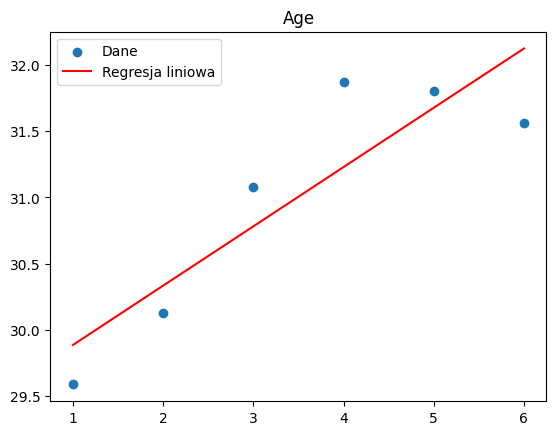

{'18 - 24': 1, '25 - 34': 2, '35 - 44': 3, '45 - 54': 4, '55 - 64': 5, '65 or older': 6}


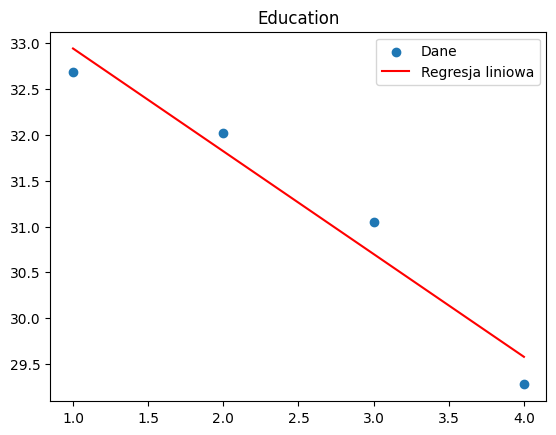

{'Less than high school': 1, 'High school graduate': 2, 'Some college or technical school': 3, 'College graduate': 4}


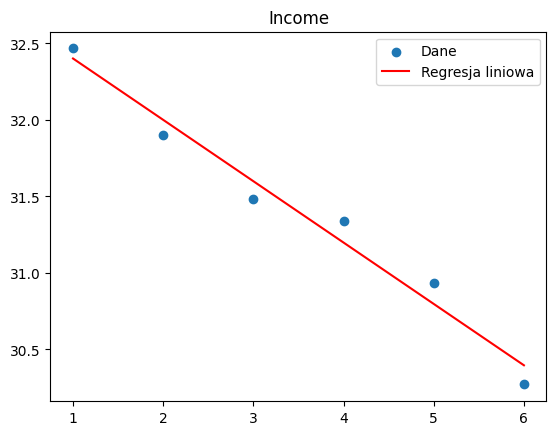

{'Less than $15,000': 1, '$15,000 - $24,999': 2, '$25,000 - $34,999': 3, '$35,000 - $49,999': 4, '$50,000 - $74,999': 5, '$75,000 or greater': 6}


In [5]:
file = pd.read_csv("data (1).csv")


# Age(years) as x => Data_Value as y
age_map = {
    "18 - 24": 1,
    "25 - 34": 2,
    "35 - 44": 3,
    "45 - 54": 4,
    "55 - 64": 5,
    "65 or older": 6
}

df_age = (file[["Age(years)", "Data_Value"]].dropna())
df_age["AgeNum"] = df_age["Age(years)"].map(age_map)
df_age = df_age.dropna(subset=["AgeNum"])
df_age_agg = (df_age.groupby("AgeNum", as_index=False).mean(numeric_only=True))
data_age = df_age_agg.to_numpy(dtype=float)

model_age = LinearRegression("Age", 0.001, 100000)
model_age.learn(data_age)
model_age.show()

print(age_map)







# Education as x => Data_Value as y
edu_map = {
    "Less than high school": 1,
    "High school graduate": 2,
    "Some college or technical school": 3,
    "College graduate": 4
}

df_edu = (file[["Education", "Data_Value"]].dropna())
df_edu["EduNum"] = df_edu["Education"].map(edu_map)
df_edu = df_edu.dropna(subset=["EduNum"])
df_edu_agg = (df_edu.groupby("EduNum", as_index=False).mean(numeric_only=True))
data_edu = df_edu_agg.to_numpy(dtype=float)

model_edu = LinearRegression("Education", 0.01, 100000)
model_edu.learn(np.array(data_edu))
model_edu.show()

print(edu_map)







# Income as x => Data_Value as y
inc_map = {
    "Less than $15,000": 1,
    "$15,000 - $24,999": 2,
    "$25,000 - $34,999": 3,
    "$35,000 - $49,999": 4,
    "$50,000 - $74,999": 5,
    "$75,000 or greater": 6
}

df_inc = (file[["Income", "Data_Value"]].dropna())
df_inc["IncomeNum"] = df_inc["Income"].map(inc_map)
df_inc = df_inc.dropna(subset=["IncomeNum"])
df_inc_agg = (df_inc.groupby("IncomeNum", as_index=False).mean(numeric_only=True))
data_inc = df_inc_agg.to_numpy(dtype=float)

model_inc = LinearRegression("Income", 0.01, 100000)
model_inc.learn(np.array(data_inc))
model_inc.show()

print(inc_map)

## Zadanie 2

### Treść:
Przeanalizuj, czy z punktu widzenia marketingowego producentowi Coca-Coli bardziej opłaca się zwiększyć promień puszki, czy też jej wysokość. W reklamie ma się pojawić komunikat o "większej objętości puszki" (wskazówka: różniczka funkcji dwóch zmiennych). Rozwiązanie powinno zawierać wszystkie obliczenia i konkluzje (Markdown)

### Rozbicie problemu:
Z punktu widzenia marketingu producent chce uzyskać jak największy wzrost objętości $\Delta V$ przy minimalnej (niemal niezauważalnej) zmianie wymiarów puszki. Pytanie brzmi: czy bardziej opłaca się zwiększyć promień $r$ czy wysokość $H$, aby uzyskać maksymalny efekt objętościowy?

### Wzory i obliczenia:
Puszka jest walcem. Objętość puszki opisujemy wzorem:
$$
V = \pi r^{2} H
$$
gdzie $H$ - to wysokość puszki, a $r$ - to promień podstawy.

---

### Różniczka zupełna objętości:

Aby zbadać, jak zmiana wymiarów wpływa na objętość, liczymy różniczkę zupełną funkcji $V(r, H)$:

$$
dV = \frac{\partial V}{\partial r}dr + \frac{\partial V}{\partial H}dH
$$

Obliczamy pochodne cząstkowe:
$$
\frac{\partial V}{\partial r} = 2\pi r H
$$
$$
\frac{\partial V}{\partial H} = \pi r^{2}
$$

Zatem:
$$
dV = 2\pi r H \cdot dr + \pi r^{2} \cdot dH
$$

---

### Analiza wrażliwości objętości:

Współczynniki przy $dr$ i $dH$ mówią nam, jak bardzo zmiana danego wymiaru wpływa na objętość:

| Zmiana | Współczynnik wrażliwości |
|--------|--------------------------|
| $dr$ (promień) | $2\pi r H$ |
| $dH$ (wysokość) | $\pi r^{2}$ |

**Porównanie:**
$$
2\pi r H \quad \text{vs} \quad \pi r^{2}
$$

Dzieląc obie strony przez $\pi r$ (gdzie $r > 0$):
$$
2H \quad \text{vs} \quad r
$$

---

### Przykład dla typowej puszki (330 ml):
- Promień: $r \approx 3.3$ cm
- Wysokość: $H \approx 12.2$ cm

Sprawdzamy:
$$
2H = 2 \cdot 12.2 = 24.4 \text{ cm}
$$
$$
r = 3.3 \text{ cm}
$$

Ponieważ $2H = 24.4 \gg r = 3.3$, to:
$$
\frac{\partial V}{\partial r} = 2\pi r H \gg \frac{\partial V}{\partial H} = \pi r^{2}
$$

---

### Sprawdzenie numeryczne:

Dla puszki o wymiarach $r = 3.3$ cm i $H = 12.2$ cm:

**Zwiększenie promienia o 1 mm ($dr = 0.1$ cm, $dH = 0$):**
$$
dV = 2\pi \cdot 3.3 \cdot 12.2 \cdot 0.1 = 2\pi \cdot 4.026 \approx 25.3 \text{ cm}^3
$$

**Zwiększenie wysokości o 1 mm ($dr = 0$, $dH = 0.1$ cm):**
$$
dV = \pi \cdot 3.3^{2} \cdot 0.1 = \pi \cdot 1.089 \approx 3.4 \text{ cm}^3
$$

**Stosunek:** $\frac{25.3}{3.4} \approx 7.4$

Czyli ta sama zmiana o 1 mm promienia daje ~7.4 razy większy przyrost objętości niż zmiana wysokości.

---

### Konkluzja:

Z punktu widzenia marketingu producentowi bardziej opłaca się zwiększyć PROMIEŃ puszki.

**Uzasadnienie:**
1. Dla typowych proporcji puszki ($H > r$) zachodzi $2H > r$, co oznacza że $\frac{\partial V}{\partial r} > \frac{\partial V}{\partial H}$
2. Minimalna, niemal niezauważalna zmiana promienia daje znacznie większy wzrost objętości niż taka sama zmiana wysokości
3. Pozwala to na reklamę "większa objętość!" przy minimalnej wizualnej zmianie produktu
4. Klient może nawet nie zauważyć zmiany kształtu puszki, ale producent może reklamować zwiększoną pojemność